In [13]:
#Importing Dataset

#!wget -O ~/face-recognition-dataset.zip https://www.kaggle.com/api/v1/datasets/download/vasukipatel/face-recognition-dataset
!unzip face-recognition-dataset.zip



Archive:  face-recognition-dataset.zip
  inflating: Dataset.csv             
  inflating: Faces/Faces/Akshay Kumar_0.jpg  
  inflating: Faces/Faces/Akshay Kumar_1.jpg  
  inflating: Faces/Faces/Akshay Kumar_10.jpg  
  inflating: Faces/Faces/Akshay Kumar_11.jpg  
  inflating: Faces/Faces/Akshay Kumar_12.jpg  
  inflating: Faces/Faces/Akshay Kumar_13.jpg  
  inflating: Faces/Faces/Akshay Kumar_14.jpg  
  inflating: Faces/Faces/Akshay Kumar_15.jpg  
  inflating: Faces/Faces/Akshay Kumar_16.jpg  
  inflating: Faces/Faces/Akshay Kumar_17.jpg  
  inflating: Faces/Faces/Akshay Kumar_18.jpg  
  inflating: Faces/Faces/Akshay Kumar_19.jpg  
  inflating: Faces/Faces/Akshay Kumar_2.jpg  
  inflating: Faces/Faces/Akshay Kumar_20.jpg  
  inflating: Faces/Faces/Akshay Kumar_21.jpg  
  inflating: Faces/Faces/Akshay Kumar_22.jpg  
  inflating: Faces/Faces/Akshay Kumar_23.jpg  
  inflating: Faces/Faces/Akshay Kumar_24.jpg  
  inflating: Faces/Faces/Akshay Kumar_25.jpg  
  inflating: Faces/Faces/Akshay K

In [14]:
import cv2
import os

# Define the folder containing the images
input_folder = "/home/jahanzaib/Math Homework/Indian Dataset/Faces/Faces"
output_folder = "processed_faces"

# Create the output directory if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Fixed size for the images
fixed_size = (100, 100)

# Iterate through all files in the input folder
for filename in os.listdir(input_folder):
    file_path = os.path.join(input_folder, filename)

    # Check if the file is an image (optional, based on your dataset structure)
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
        try:
            # Read the image
            img = cv2.imread(file_path)
            if img is None:
                print(f"Skipping {filename}: unable to read file.")
                continue

            # Convert the image to grayscale
            gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Resize the image to the fixed size
            resized_img = cv2.resize(gray_img, fixed_size)

            # Extract the celebrity's name from the filename (assuming the format "Name_X.jpg")
            celeb_name = " ".join(filename.split("_")[:-1])
            celeb_folder = os.path.join(output_folder, celeb_name)

            # Create a folder for the celebrity if it doesn't exist
            os.makedirs(celeb_folder, exist_ok=True)

            # Save the processed image to the celebrity's folder
            output_path = os.path.join(celeb_folder, filename)
            cv2.imwrite(output_path, resized_img)

            print(f"Processed and saved: {filename} in {celeb_folder}")
        except Exception as e:
            print(f"Error processing {filename}: {e}")

print("Processing complete. All images are organized by celebrity in the 'processed_faces' folder.")


Processed and saved: Hrithik Roshan_39.jpg in processed_faces/Hrithik Roshan
Processed and saved: Billie Eilish_12.jpg in processed_faces/Billie Eilish
Processed and saved: Billie Eilish_31.jpg in processed_faces/Billie Eilish
Processed and saved: Henry Cavill_101.jpg in processed_faces/Henry Cavill
Processed and saved: Alexandra Daddario_61.jpg in processed_faces/Alexandra Daddario
Processed and saved: Zac Efron_17.jpg in processed_faces/Zac Efron
Processed and saved: Priyanka Chopra_13.jpg in processed_faces/Priyanka Chopra
Processed and saved: Lisa Kudrow_7.jpg in processed_faces/Lisa Kudrow
Processed and saved: Hugh Jackman_71.jpg in processed_faces/Hugh Jackman
Processed and saved: Lisa Kudrow_10.jpg in processed_faces/Lisa Kudrow
Processed and saved: Courtney Cox_74.jpg in processed_faces/Courtney Cox
Processed and saved: Vijay Deverakonda_47.jpg in processed_faces/Vijay Deverakonda
Processed and saved: Vijay Deverakonda_37.jpg in processed_faces/Vijay Deverakonda
Processed and s

In [16]:
import os
import cv2
import numpy as np
import torch

# Step 1: Load the dataset
base_path = "processed_faces"
celeb_folders = [folder for folder in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, folder))]

faces = []
labels = []

for celeb in celeb_folders:
    celeb_path = os.path.join(base_path, celeb)
    celeb_images = [img for img in os.listdir(celeb_path) if img.endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_name in celeb_images:
        img_path = os.path.join(celeb_path, img_name)
        image = cv2.imread(img_path)
        image = cv2.resize(image, (47, 62))  # Resize to a fixed size
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        faces.append(gray_image.flatten())  # Flatten the image
        labels.append(celeb)

# Step 2: Prepare data for PCA
X = np.array(faces)
y = np.array(labels)

# Step 3: Compute the mean face
mean_face = np.mean(X, axis=0)

# Step 4: Center the data
centered_data = X - mean_face

# Step 5: Compute the covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)

# Step 6: Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 7: Sort eigenvalues and eigenvectors
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# Step 8: Select top N eigenfaces
N = 10  # Number of eigenfaces to keep
eigenfaces = sorted_eigenvectors[:, :N]

# Step 9: Project images onto eigenfaces
projected_faces = np.dot(centered_data, eigenfaces)

# Convert to PyTorch tensors if needed
projected_faces_tensor = torch.tensor(projected_faces)

# Now you can use projected_faces_tensor for further processing or classification

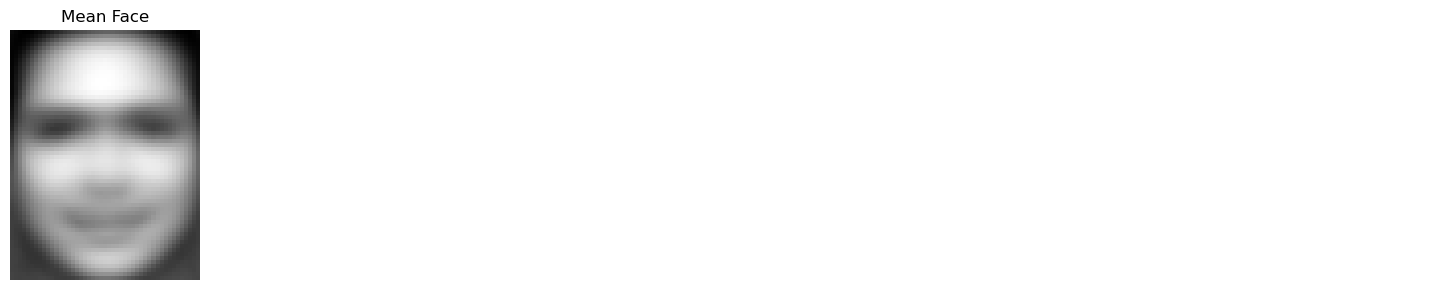

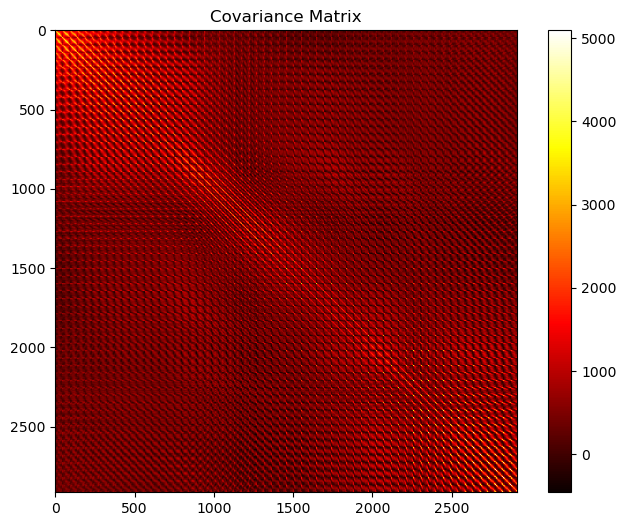

TypeError: Image data of dtype complex128 cannot be converted to float

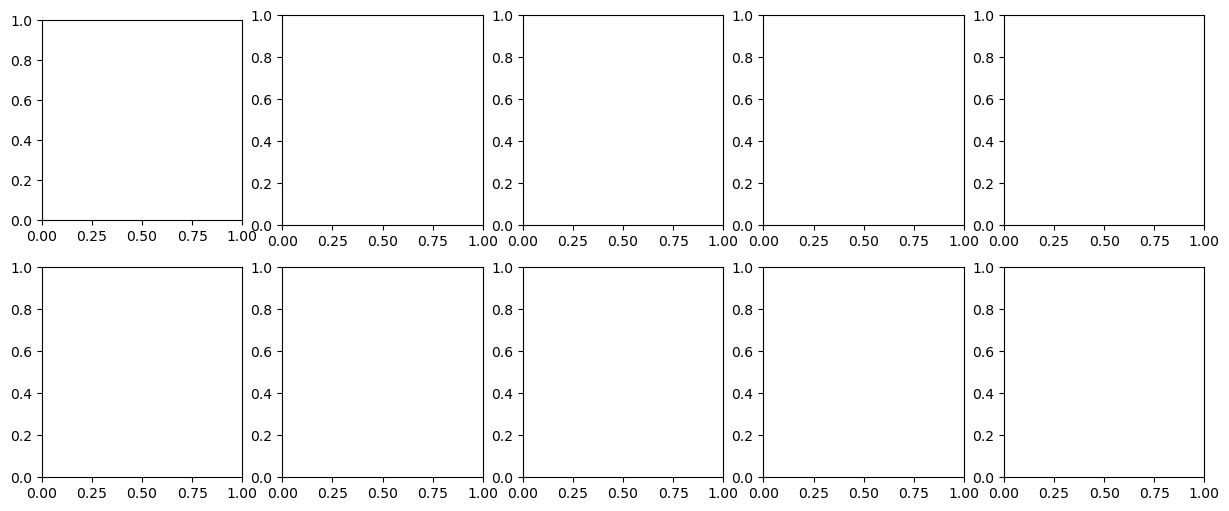